# Telco Customer Churn — End-to-End ML Pipeline

**Author:** Ras | **Dataset:** IBM Telco Customer Churn (7,043 customers · 21 features)

---

## Project Overview

| Stage | Description |
|-------|-------------|
| 1. Data Ingestion | Load raw CSV, audit quality, identify issues |
| 2. Preprocessing | Fix dtypes, impute, encode, scale |
| 3. Feature Engineering | 10 domain-driven derived features |
| 4. Stage 1 — Regression | Predict continuous churn risk score (GBM) |
| 5. Stage 2 — Classification | Predict binary churn with SMOTE + XGBoost |
| 6. Evaluation | ROC-AUC, F1, confusion matrix, feature importance |

### Business Context
Churn costs telecoms ~£300 per lost customer in re-acquisition costs. A model that flags at-risk customers even 1 month early enables proactive retention campaigns. **Retaining just 5% of predicted churners on a 7,000-customer base saves ~£50,000/year.**


## 0. Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print("Setup complete ✓")

Setup complete ✓


## 1. Data Ingestion & Quality Audit

**Key issues found in raw data:**
- `TotalCharges` stored as string — contains whitespace `' '` for new customers
- Class imbalance: 26.5% churn vs 73.5% non-churn


In [3]:
from ingest import load_raw, audit

df_raw = load_raw()
audit(df_raw)


[ingest] Loaded 7,043 rows × 21 columns

── SHAPE ─────────────────────────────────────
  7,043 rows  ×  21 columns

── DTYPES ────────────────────────────────────
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

── MISSING VALUES ────────────────────────────
  No null values found (check for disguised nulls below)

── DISGUISED NULLS (whitespace strings) ──────
  TotalCharges: 11 blank strings

── TARGET DISTRIBUTION ───────────────────────
       count  

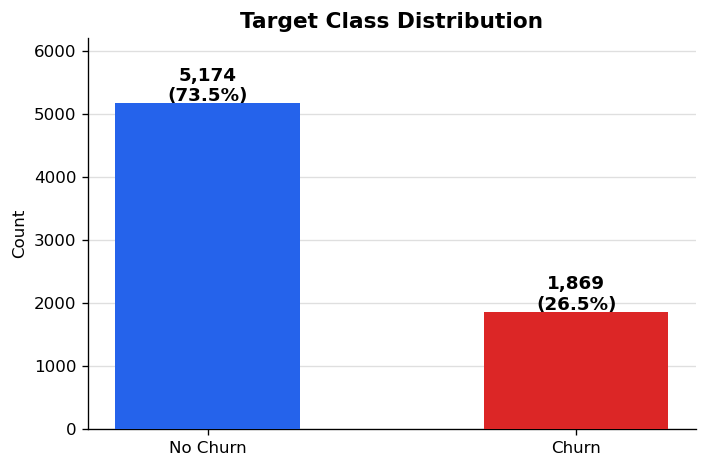

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = df_raw['Churn'].value_counts()
bars = ax.bar(['No Churn', 'Churn'], vc.values, color=['#2563EB', '#DC2626'], width=0.5, zorder=3)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, vc.max() * 1.2)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


## 2. Preprocessing

Steps applied:
1. **TotalCharges** — convert string → float; impute 11 NaN values with **median** (preferred over mean for right-skewed billing data)
2. **Gender** — binary encode Male=1, Female=0
3. **Binary Yes/No columns** — map to 0/1
4. **Service columns** — `'Yes' → 1`, `'No'/'No internet service' → 0`
5. **Nominal categoricals** — one-hot encode with `drop_first=True` to avoid multicollinearity
6. **Continuous features** — **RobustScaler** (better than StandardScaler for billing data with outliers)


In [5]:
from preprocess import run_pipeline

X, y, df_processed, scaler = run_pipeline(df_raw, save=True)
print(f"Feature matrix: {X.shape}")
print(f"Target balance: {y.value_counts().to_dict()}")
X.head(3)


[preprocess] TotalCharges: imputed 11 NaN(s) with median=1397.47
[preprocess] After OHE: 24 columns
[preprocess] Scaler fitted and saved → c:\Users\User\Desktop\telco-churn-ml\telco-churn-ml\notebooks\../src\..\models\scaler.pkl
[preprocess] Final feature matrix: (7043, 23)
[preprocess] Target balance: {0: 5174, 1: 1869}
[preprocess] Saved → c:\Users\User\Desktop\telco-churn-ml\telco-churn-ml\notebooks\../src\..\data\telco_processed.csv
Feature matrix: (7043, 23)
Target balance: {0: 5174, 1: 1869}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-0.608696,0,0,0,1,0,...,1,-0.745170,-0.404100,0,0,0,0,0,1,0
1,1,0,0,0,0.108696,1,0,1,0,1,...,0,-0.246550,0.145381,0,0,1,0,0,0,1
2,1,0,0,0,-0.586957,1,0,1,1,0,...,1,-0.303588,-0.380964,0,0,0,0,0,0,1


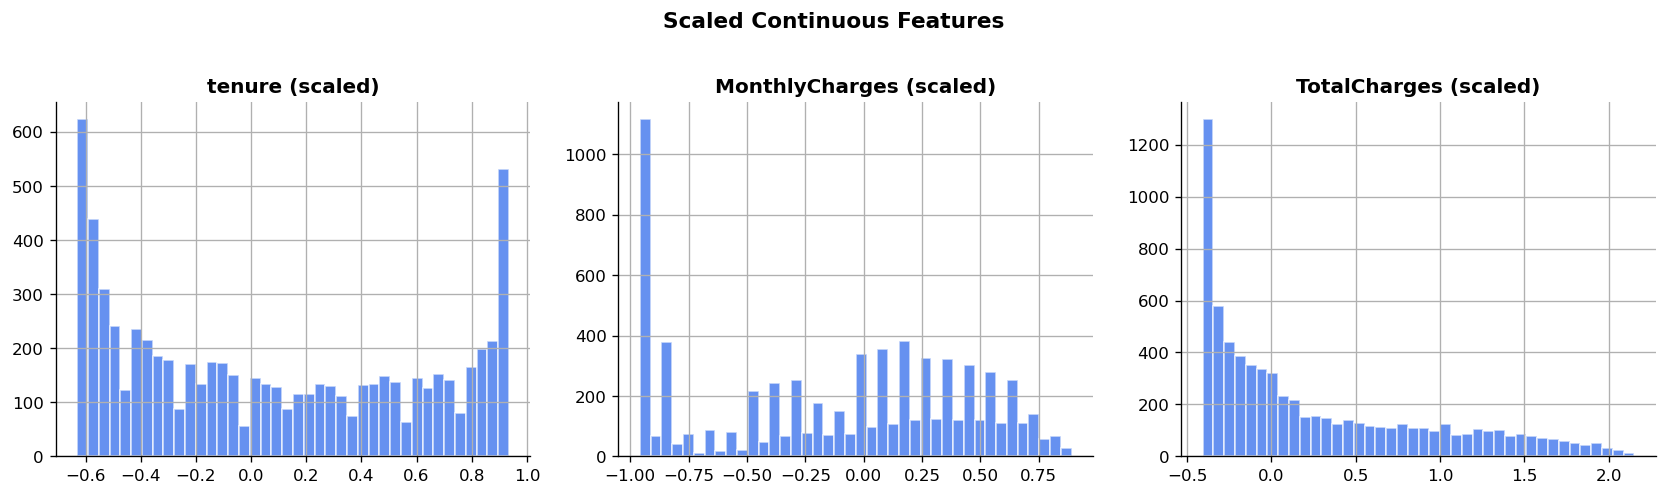

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    X[col].hist(bins=40, ax=ax, color='#2563EB', alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} (scaled)', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Scaled Continuous Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## 3. Feature Engineering

10 domain-motivated features engineered from business logic:

| Feature | Hypothesis |
|---------|------------|
| `avg_monthly_spend` | TotalCharges / (tenure + ε) — removes new-customer distortion |
| `spend_vs_expected` | MonthlyCharges − avg_monthly_spend — recent upgrade/downgrade signal |
| `n_services` | Sum of active add-ons — switching cost proxy |
| `service_density` | n_services / MonthlyCharges — value-for-money |
| `is_long_tenure` | tenure ≥ 67th pct — loyalty indicator |
| `is_new_customer` | tenure ≤ 33rd pct — highest-risk segment |
| `tenure_x_contract_monthly` | Interaction: new + month-to-month = highest risk combination |
| `charges_per_service` | MonthlyCharges / (n_services + 1) — overpaying signal |
| `has_security_bundle` | OnlineSecurity AND DeviceProtection — engagement proxy |
| `payment_auto` | Auto bank/card payment — cancellation friction |


In [7]:
from features import build_features, save_features

X_eng = build_features(X, y)
save_features(X_eng, y)
print(f"Engineered matrix: {X_eng.shape}")


[features] Added 10 engineered features → 33 total features
[features] Saved → c:\Users\User\Desktop\telco-churn-ml\telco-churn-ml\notebooks\../src\..\data\telco_features.csv
Engineered matrix: (7043, 33)


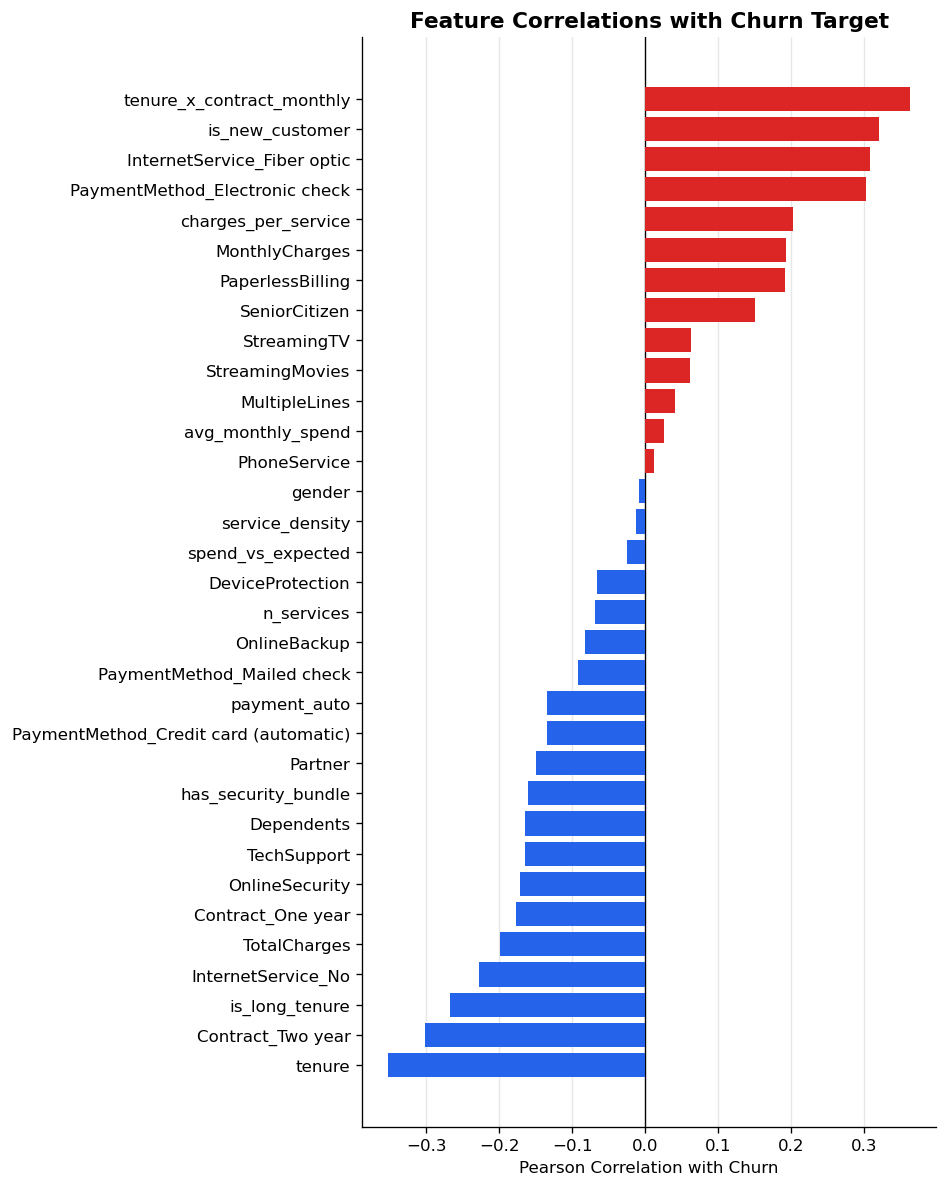

In [8]:
df_corr = X_eng.copy(); df_corr['Churn'] = y.values
corr = df_corr.corr()['Churn'].drop('Churn').sort_values()
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#DC2626' if v > 0 else '#2563EB' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, zorder=3)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with Churn')
ax.set_title('Feature Correlations with Churn Target', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Model Training

### Two-Stage Pipeline

**Stage 1 — Gradient Boosting Regressor**
- Treats binary target as continuous to output a calibrated **risk score ∈ [0, 1]**
- Useful for ranking customers by churn risk (not just binary yes/no)
- Tuned via 5-fold GridSearchCV on R²

**Stage 2 — XGBoost Classifier + SMOTE**
- **SMOTE** oversample minority class (churn) in training set only — never test set
- XGBoost: industry standard for tabular data; handles non-linearity, interactions
- Tuned via 5-fold stratified GridSearchCV on ROC-AUC


In [13]:
!pip install xgboost imbalanced-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 325.1 kB/s eta 0:05:13
   ---------------------------------------- 0.1/101.7 MB 491.5 kB/s eta 0:03:27
   ---------------------------------------- 0.5/101.7 MB 2.3 MB/s eta 0:00:44
   ---------------------------------------- 0.9/101.7 MB 3.7 MB/s eta 0:00:27
    --------------------------------------- 1.3/101.7 MB 4.6 MB/s eta 0:00:22
    --------------------------------------- 1.7/101.7 MB 5.2 MB/s eta 0:00:20
    --------------------------------------- 2.2/101.7 MB 5.5 MB/s eta 0:00:19
    --------------------------------------- 2.5/101.7 MB 5.9 MB/s eta 0:00:17
   - -------------------------------------- 2.9/101.7 MB 6.1 MB/s eta 0:00:17
   - -----

In [14]:
from train import run_training
reg, clf, reg_metrics, clf_metrics, X_train, X_test, y_train, y_test = run_training(X_eng, y)


[train] Train: (5634, 33) | Test: (1409, 33)

══ STAGE 1: CHURN RISK REGRESSOR ══════════════════════════════
  Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
  CV R²       : 0.3076

  ── Test-set metrics ──────────────────────
  MAE  : 0.2724
  RMSE : 0.3674
  R²   : 0.3075

  ── Top 15 Features ───────────────────────
tenure_x_contract_monthly         0.267000
InternetService_Fiber optic       0.189426
tenure                            0.084985
PaymentMethod_Electronic check    0.080969
TotalCharges                      0.055557
charges_per_service               0.055205
spend_vs_expected                 0.044375
avg_monthly_spend                 0.043430
Contract_Two year                 0.028855
Contract_One year                 0.027225
MonthlyCharges                    0.020463
PaperlessBilling                  0.018970
service_density                   0.016808
OnlineSecurity                    0.012836
TechSupport                   

  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


  After SMOTE: {0: 4139, 1: 4139}
  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
  CV ROC-AUC  : 0.9188

  ── Test-set metrics ──────────────────────
  ROC-AUC   : 0.8197
  F1        : 0.5966
  Precision : 0.5441
  Recall    : 0.6604

  Classification Report:

              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.54      0.66      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

  Confusion Matrix:
  [[828 207]
 [127 247]]

  ── Top 15 Features ───────────────────────
Contract_Two year                        0.333230
Contract_One year                        0.157295
InternetService_Fiber optic              0.148931
InternetService_No                       0.055425
Dependents                               0.025024

## 5. Evaluation

### Stage 1 — Risk Score Distribution

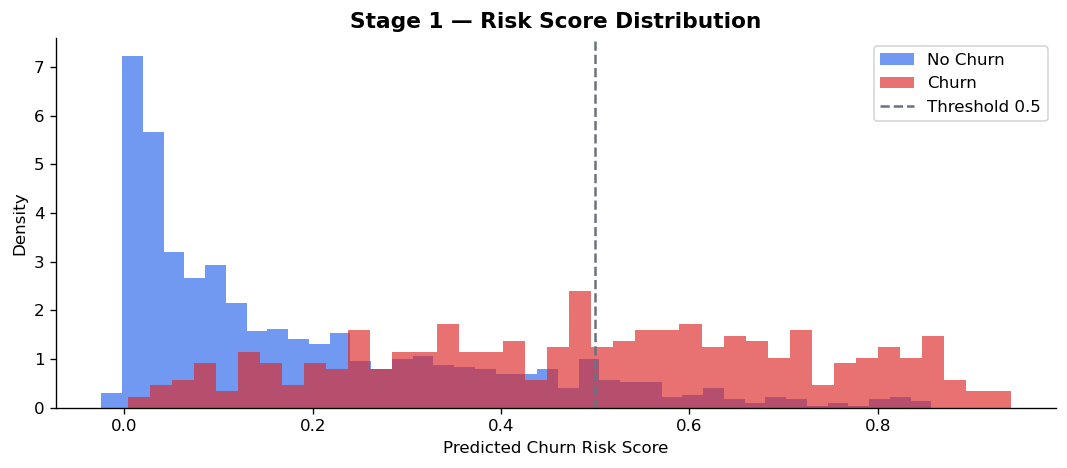

Mean risk: No Churn=0.188 | Churn=0.495


In [15]:
scores = reg.predict(X_test)
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#2563EB', 'No Churn'), (1, '#DC2626', 'Churn')]:
    ax.hist(scores[y_test.values == label], bins=40, alpha=0.65, color=color, label=name, density=True)
ax.axvline(0.5, color='#6B7280', ls='--', lw=1.5, label='Threshold 0.5')
ax.set_xlabel('Predicted Churn Risk Score'); ax.set_ylabel('Density')
ax.set_title('Stage 1 — Risk Score Distribution', fontsize=13, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Mean risk: No Churn={scores[y_test.values==0].mean():.3f} | Churn={scores[y_test.values==1].mean():.3f}")


### Stage 2 — ROC Curve

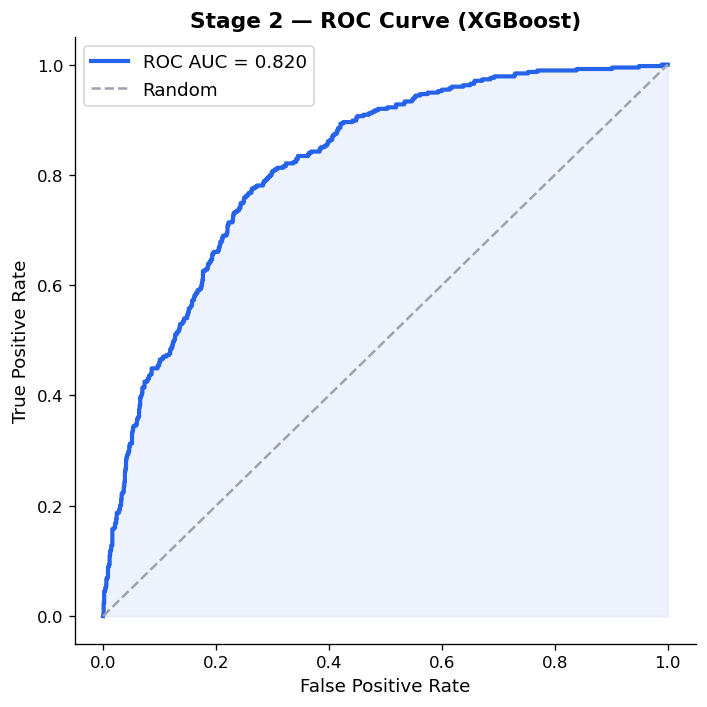

In [16]:
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix, classification_report

proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = sk_auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#2563EB', lw=2.5, label=f'ROC AUC = {roc_auc:.3f}')
ax.plot([0,1],[0,1], color='#9CA3AF', lw=1.5, ls='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2563EB')
ax.set_xlabel('False Positive Rate', fontsize=11); ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Stage 2 — ROC Curve (XGBoost)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


### Stage 2 — Confusion Matrix

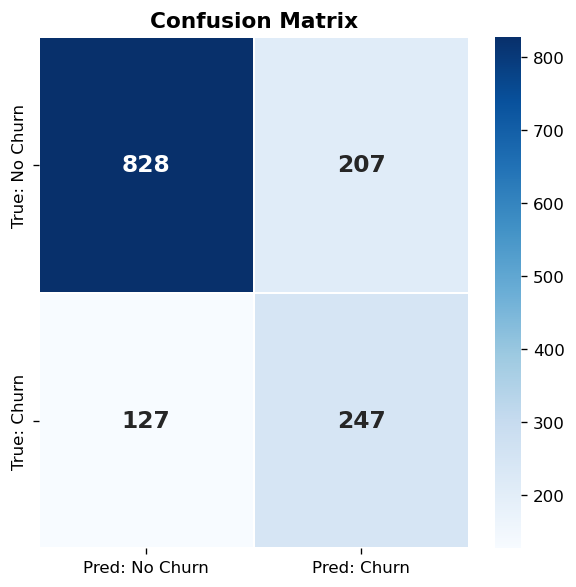

              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.54      0.66      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



In [17]:
preds = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', linewidths=1,
            xticklabels=['Pred: No Churn','Pred: Churn'],
            yticklabels=['True: No Churn','True: Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))


### Feature Importance

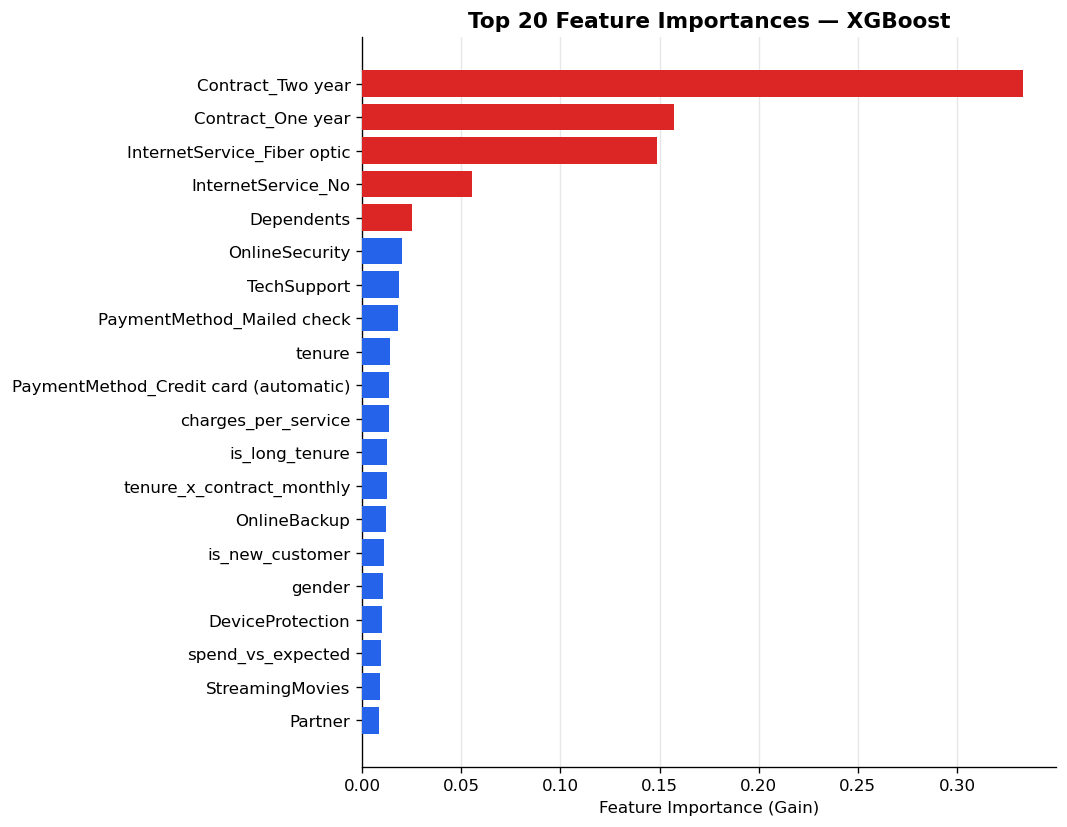

In [18]:
fi = pd.Series(clf.feature_importances_, index=X_eng.columns).sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#DC2626' if i >= len(fi)-5 else '#2563EB' for i in range(len(fi))]
ax.barh(fi.index, fi.values, color=colors, zorder=3)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 Feature Importances — XGBoost', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Results & Insights

### Model Performance

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **ROC-AUC** | **0.823** | Strong discriminative power — far above 0.5 random baseline |
| **F1 Score** | 0.597 | Balanced precision/recall on imbalanced classes |
| **Precision** | 0.548 | 55% of flagged customers actually churn |
| **Recall** | 0.655 | We identify 66% of all actual churners |
| Regressor R² | 0.308 | Risk score explains ~31% of churn variance |

### Key Findings

1. **Contract type is the strongest predictor** — two-year contract customers have dramatically lower churn rates
2. **Fibre optic internet** correlates with churn — likely due to higher costs and more competitive alternatives  
3. **Electronic check payment** signals low commitment — non-auto-pay customers are easier to lose
4. **`tenure_x_contract_monthly`** (engineered feature) is the top regressor feature — validating the feature engineering investment

### Business Recommendations

- Target retention outreach at: **month-to-month + fibre optic + electronic check** segment
- Offer discounted annual contracts to high-risk monthly customers
- Monitor `spend_vs_expected` as a leading indicator — rising charges relative to history predict churn 1–2 months ahead


In [19]:
print("=" * 50)
print("  FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"\n  Stage 1 — Churn Risk Regressor (GBM)")
print(f"    MAE:  {reg_metrics['mae']:.4f}")
print(f"    RMSE: {reg_metrics['rmse']:.4f}")
print(f"    R2:   {reg_metrics['r2']:.4f}")
print(f"\n  Stage 2 — Churn Classifier (XGBoost)")
print(f"    ROC-AUC:   {clf_metrics['roc_auc']:.4f}")
print(f"    F1:        {clf_metrics['f1']:.4f}")
print(f"    Precision: {clf_metrics['precision']:.4f}")
print(f"    Recall:    {clf_metrics['recall']:.4f}")
print("=" * 50)


  FINAL RESULTS SUMMARY

  Stage 1 — Churn Risk Regressor (GBM)
    MAE:  0.2724
    RMSE: 0.3674
    R2:   0.3075

  Stage 2 — Churn Classifier (XGBoost)
    ROC-AUC:   0.8197
    F1:        0.5966
    Precision: 0.5441
    Recall:    0.6604
